# Analiza EuroSAT RGB skupa podataka pre treniranja modela

In [1]:
import sys
import torch
import torchvision

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

Python: c:\Users\Georgios\DPN_EuroSAT\.venv\Scripts\python.exe
PyTorch: 2.14.0+cpu
Torchvision: 0.29.0+cpu


In [2]:
from pathlib import Path

project_path = Path.cwd()

if project_path.name == "notebooks":
    project_path = project_path.parent
        
data_path = project_path / "data" / "raw"

print("Folder projekta:", project_path)
print("Folder sa podacima:", data_path)

Folder projekta: c:\Users\Georgios\DPN_EuroSAT
Folder sa podacima: c:\Users\Georgios\DPN_EuroSAT\data\raw


# Ucitavanje skupa

In [3]:
from torchvision.datasets import EuroSAT

dataset = EuroSAT(root=data_path, download=True)

print("Broj slika:", len(dataset))
print("Broj klasa:", len(dataset.classes))
print("Klase:", dataset.classes)

Broj slika: 27000
Broj klasa: 10
Klase: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


# Provera jedne slike

Tip slike: <class 'PIL.Image.Image'>
Dimenzije: (64, 64)
Oznaka klase: 0
Naziv klase: AnnualCrop


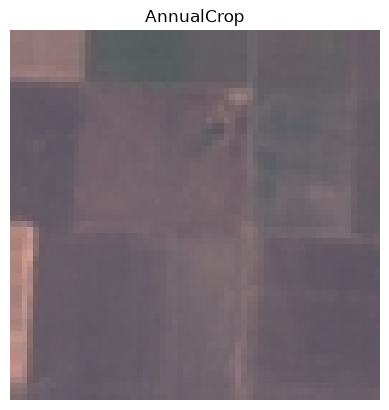

In [4]:
import matplotlib.pyplot as plt

image, label = dataset[0]

print("Tip slike:", type(image))
print("Dimenzije:", image.size)
print("Oznaka klase:", label)
print("Naziv klase:", dataset.classes[label])

plt.imshow(image)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

# Biranje sest random slika

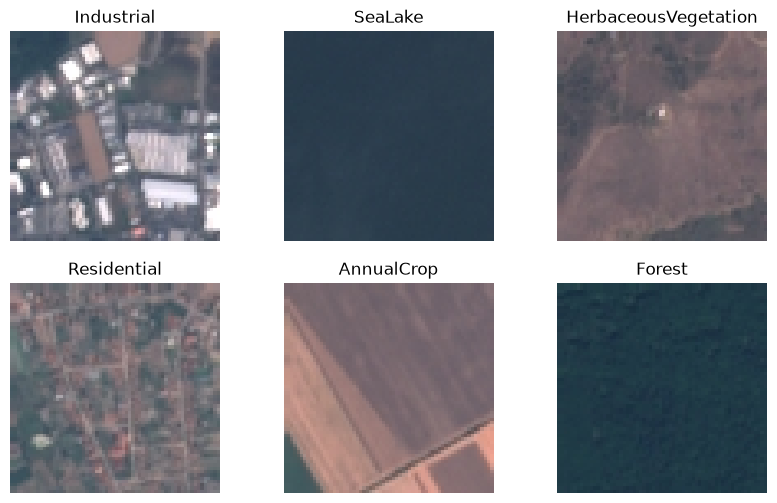

In [5]:
import random

plt.figure(figsize=(10, 6))

for i in range(6):
    index = random.randint(0, len(dataset) - 1)
    image, label = dataset[index]

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(dataset.classes[label])
    plt.axis("off")

plt.show()

In [6]:
for i in range(len(dataset.classes)):
    count = dataset.targets.count(i)
    print(dataset.classes[i], "-", count)


AnnualCrop - 3000
Forest - 3000
HerbaceousVegetation - 3000
Highway - 2500
Industrial - 2500
Pasture - 2000
PermanentCrop - 2500
Residential - 3000
River - 2500
SeaLake - 3000


# Prikaz broja slika po klasama

<function matplotlib.pyplot.show(close=None, block=None)>

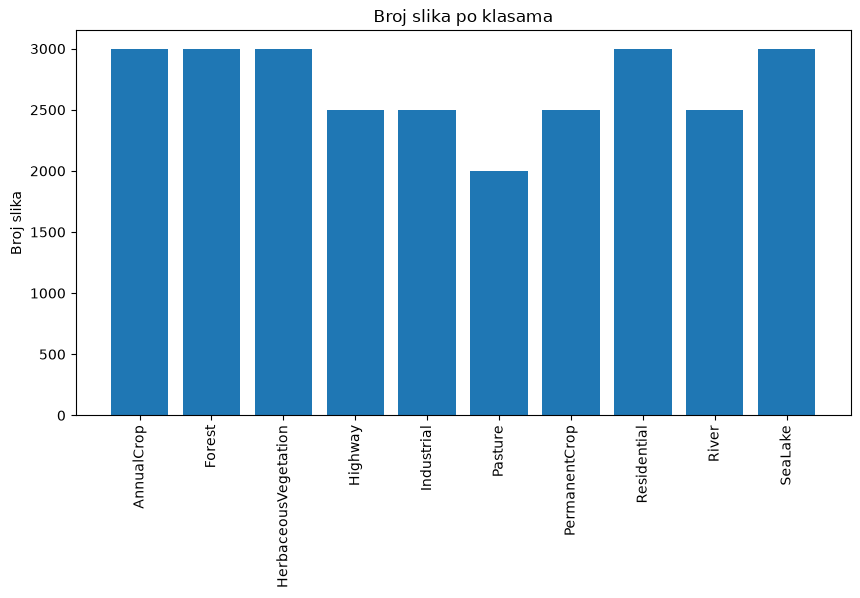

In [7]:
class_counts = []

for i in range(len(dataset.classes)):
    class_counts.append(dataset.targets.count(i))

plt.figure(figsize=(10, 5))
plt.bar(dataset.classes, class_counts)
plt.xticks(rotation=90)
plt.ylabel("Broj slika")
plt.title("Broj slika po klasama")
plt.show

# Preuzimanje .txt fajla sa gotovim podelama na trening, test i validaciju

In [8]:
from urllib.request import urlretrieve

split_path = project_path / "data" / "splits"
url = "https://huggingface.co/datasets/torchgeo/eurosat/resolve/main/"

urlretrieve(url + "eurosat-train.txt", split_path / "eurosat-train.txt")
urlretrieve(url + "eurosat-val.txt", split_path / "eurosat-val.txt")
urlretrieve(url + "eurosat-test.txt", split_path / "eurosat-test.txt")

print("Fajlovi za podelu su preuzeti")

with open(split_path / "eurosat-train.txt") as f:
    train_names = f.read().splitlines()

with open(split_path / "eurosat-val.txt") as f:
    val_names = f.read().splitlines()

with open(split_path / "eurosat-test.txt") as f:
    test_names = f.read().splitlines()

print("Trening:", len(train_names))
print("Validacija:", len(val_names))
print("Test:", len(test_names))


Fajlovi za podelu su preuzeti
Trening: 16200
Validacija: 5400
Test: 5400


# Povezivanje indeksa slika sa podacima iz .txt fajla

In [9]:
train_names = set(train_names)
val_names = set(val_names)
test_names = set(test_names)

train_indices = []
val_indices = []
test_indices = []

for i in range(len(dataset)):
    file_name = Path(dataset.samples[i][0]).name

    if file_name in train_names:
        train_indices.append(i)
    elif file_name in val_names:
        val_indices.append(i)
    elif file_name in test_names:
        test_indices.append(i)

print("Trening:", len(train_indices))
print("Validacija:", len(val_indices))
print("Test:", len(test_indices))

Trening: 16200
Validacija: 5400
Test: 5400


# Pravljenje Subsetova

In [10]:
from torch.utils.data import Subset

train_data = Subset(dataset, train_indices)
val_data = Subset(dataset, val_indices)
test_data = Subset(dataset, test_indices)

print("Trening skup:", len(train_data))
print("Validacioni skup:", len(val_data))
print("Test skup:", len(test_data))

Trening skup: 16200
Validacioni skup: 5400
Test skup: 5400


# Pretvaranje prve slike u tensor i provera svega

In [11]:
from torchvision import transforms

image, label = train_data[0]

to_tensor = transforms.ToTensor()
image_tensor = to_tensor(image)

print("Pre pretvaranja:", type(image))
print("Posle pretvaranja:", type(image_tensor))
print("Dimenzije tenzora:", image_tensor.shape)
print("Najmanja vrednost:", image_tensor.min().item())
print("Najveca vrednost:", image_tensor.max().item())

Pre pretvaranja: <class 'PIL.Image.Image'>
Posle pretvaranja: <class 'torch.Tensor'>
Dimenzije tenzora: torch.Size([3, 64, 64])
Najmanja vrednost: 0.32156863808631897
Najveca vrednost: 0.800000011920929


# Normalizacija i augmentacija

In [12]:
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    basic_transform
])

# Konacni skupovi sa transformacijama

In [13]:
train_dataset = EuroSAT(
    root=data_path,
    transform=train_transform
)

eval_dataset = EuroSAT(
    root=data_path,
    transform=basic_transform
)

train_data = Subset(train_dataset, train_indices)
val_data = Subset(eval_dataset, val_indices)
test_data = Subset(eval_dataset, test_indices)

image, label = train_data[0] # provera

print("Trening:", len(train_data))
print("Validacija:", len(val_data))
print("Test:", len(test_data))
print("Dimenzije slike:", image.shape)

Trening: 16200
Validacija: 5400
Test: 5400
Dimenzije slike: torch.Size([3, 64, 64])


# DataLoader

In [14]:
from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

print("Broj trening grupa:", len(train_loader))
print("Broj validacionih grupa:", len(val_loader))
print("Broj test grupa:", len(test_loader))

Broj trening grupa: 254
Broj validacionih grupa: 85
Broj test grupa: 85
